# Fraud Detection Feature Engineering

## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math
warnings.filterwarnings("ignore")

## Load and Inspect Data

In [4]:
# Load dataset
df = pd.read_csv("simulated-data-raw1.csv")

# Initial inspection
print("First 5 rows:")
display(df.head())

print("\nRandom 10 rows:")
display(df.sample(10))

print("\nDataset info:")
df.info()

print("\nDescriptive statistics:")
display(df.describe())

print("\nFraud distribution:")
display(df["TX_FRAUD"].value_counts())

print("\nFraud scenario distribution:")
display(df["TX_FRAUD_SCENARIO"].value_counts())

print("\nMissing values:")
display(df.isnull().sum())

First 5 rows:


,Unnamed: 0,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,0,2024-04-01 00:00:31,596,1337,57.16,31,0,0,0
1,1,1,2024-04-01 00:07:56,2,523,146.00,476,0,0,0
2,2,2,2024-04-01 00:10:34,927,824,50.99,634,0,0,0
3,3,3,2024-04-01 00:10:45,568,4805,44.71,645,0,0,0
4,4,4,2024-04-01 00:13:44,541,3260,59.07,824,0,0,0



Random 10 rows:


,Unnamed: 0,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
376312,376312,376312,2024-06-18 13:12:08,160,721,533.05,6786728,78,1,3
231979,231979,231979,2024-05-19 11:06:14,448,4649,49.52,4187174,48,0,0
115471,115471,115471,2024-04-25 06:33:29,12,1604,62.80,2097209,24,0,0
163226,163226,163226,2024-05-05 05:33:10,630,251,43.97,2957590,34,0,0
186304,186304,186304,2024-05-09 19:32:54,1259,1437,7.87,3353574,38,0,0
249416,249416,249416,2024-05-23 03:29:39,188,16,22.74,4505379,52,0,0
150275,150275,150275,2024-05-02 10:21:35,1073,4968,68.44,2715695,31,0,0
101459,101459,101459,2024-04-22 08:31:46,681,333,98.40,1845106,21,0,0
27214,27214,27214,2024-04-06 15:08:41,1471,504,20.68,486521,5,0,0
13243,13243,13243,2024-04-03 15:44:41,2260,4592,51.63,229481,2,0,0



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383087 entries, 0 to 383086
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         383087 non-null  int64  
 1   TRANSACTION_ID     383087 non-null  int64  
 2   TX_DATETIME        383087 non-null  object 
 3   CUSTOMER_ID        383087 non-null  int64  
 4   TERMINAL_ID        383087 non-null  int64  
 5   TX_AMOUNT          383087 non-null  float64
 6   TX_TIME_SECONDS    383087 non-null  int64  
 7   TX_TIME_DAYS       383087 non-null  int64  
 8   TX_FRAUD           383087 non-null  int64  
 9   TX_FRAUD_SCENARIO  383087 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 29.2+ MB

Descriptive statistics:


...

TX_FRAUD
0    377320
1      5767
Name: count, dtype: int64


Fraud scenario distribution:


TX_FRAUD_SCENARIO
0    377320
2      3681
3      1891
1       195
Name: count, dtype: int64


Missing values:


Unnamed: 0           0
TRANSACTION_ID       0
TX_DATETIME          0
CUSTOMER_ID          0
TERMINAL_ID          0
TX_AMOUNT            0
TX_TIME_SECONDS      0
TX_TIME_DAYS         0
TX_FRAUD             0
TX_FRAUD_SCENARIO    0
dtype: int64

## Feature Engineering

In [5]:
# Create a copy for transformations
df_transformed = df.copy(deep=True)

# Sort by customer and time for temporal features
df_transformed = df_transformed.sort_values(['CUSTOMER_ID', 'TX_TIME_SECONDS'])

# Convert to datetime
df_transformed['TX_DATETIME'] = pd.to_datetime(df_transformed['TX_DATETIME'])

### Temporal Features

In [6]:
# Transactions in last hour features
df_transformed['TXs_LAST_1H'] = 0
df_transformed['AMOUNT_LAST_1H'] = 0.0

for cust_id in df_transformed['CUSTOMER_ID'].unique():
    cust_mask = df_transformed['CUSTOMER_ID'] == cust_id
    cust_df = df_transformed[cust_mask]
    
    for idx, row in cust_df.iterrows():
        time_mask = (cust_df['TX_TIME_SECONDS'] >= (row['TX_TIME_SECONDS'] - 3600)) & \
                    (cust_df['TX_TIME_SECONDS'] <= row['TX_TIME_SECONDS'])
        past_txns = cust_df[time_mask]
        
        df_transformed.loc[idx, 'TXs_LAST_1H'] = len(past_txns)
        df_transformed.loc[idx, 'AMOUNT_LAST_1H'] = past_txns['TX_AMOUNT'].sum()

# Time-based features
df_transformed['TX_HOUR'] = df_transformed['TX_DATETIME'].dt.hour
df_transformed['TX_DAY'] = df_transformed['TX_DATETIME'].dt.dayofweek + 1  # Monday=1,...,Sunday=7
df_transformed['TX_IS_WEEKEND'] = (df_transformed['TX_DAY'] >= 6).astype(int)
df_transformed['TX_HOUR_CATEGORY'] = pd.cut(df_transformed['TX_HOUR'],
                                          bins=[0, 6, 12, 18, 24],
                                          labels=['Night', 'Morning', 'Afternoon', 'Evening'],
                                          right=False)

# Time periods for aggregation
df_transformed['Week'] = df_transformed['TX_TIME_DAYS'] // 7
df_transformed['Month'] = df_transformed['TX_TIME_DAYS'] // 30

### Customer Behavior Features

In [7]:
# Customer transaction patterns
def calculate_avg_ratio(group):
    return (group['TX_AMOUNT'] / group['TX_AMOUNT'].mean()).round(2)

# Amount to average ratios
df_transformed['AMOUNT_TO_AVG'] = df_transformed.groupby('CUSTOMER_ID').apply(calculate_avg_ratio).reset_index(level=0, drop=True)
df_transformed['AMOUNT_TO_AVG_DAY'] = df_transformed.groupby(['CUSTOMER_ID', 'TX_TIME_DAYS']).apply(calculate_avg_ratio).reset_index(level=[0,1], drop=True)
df_transformed['AMOUNT_TO_AVG_WEEK'] = df_transformed.groupby(['CUSTOMER_ID', 'Week']).apply(calculate_avg_ratio).reset_index(level=[0,1], drop=True)
df_transformed['AMOUNT_TO_AVG_MONTH'] = df_transformed.groupby(['CUSTOMER_ID', 'Month']).apply(calculate_avg_ratio).reset_index(level=[0,1], drop=True)

# Customer standard deviation and z-score
def calculate_z_score(group):
    mean = group['TX_AMOUNT'].mean()
    std = group['TX_AMOUNT'].std()
    if std == 0:
        return pd.Series(0, index=group.index)
    return (group['TX_AMOUNT'] - mean) / std

df_transformed['CUSTOMER_STD'] = df_transformed.groupby('CUSTOMER_ID')['TX_AMOUNT'].transform('std').fillna(0).round(2)
df_transformed['Z_SCORE'] = df_transformed.groupby('CUSTOMER_ID').apply(calculate_z_score).reset_index(level=0, drop=True)
df_transformed['Z_SCORE'] = df_transformed['Z_SCORE'].replace([np.inf, -np.inf], np.nan).fillna(0).round(2)

# Customer frequency features
df_transformed['CUSTOMER_TX_FREQ'] = df_transformed.groupby('CUSTOMER_ID')['CUSTOMER_ID'].transform('count')
df_transformed['CUSTOMER_AVG_AMOUNT'] = df_transformed.groupby('CUSTOMER_ID')['TX_AMOUNT'].transform('mean')

# Time since last transaction
df_transformed['TIME_SINCE_LAST_TX'] = df_transformed.groupby('CUSTOMER_ID')['TX_TIME_SECONDS'].diff().fillna(-1)

### Terminal Usage Features

In [8]:
# Terminal usage patterns
df_transformed['NEW_TERMINAL_FLAG'] = df_transformed.groupby('CUSTOMER_ID')['TERMINAL_ID'].transform(
    lambda x: (x != x.shift()).astype(int)
)

# Multiple terminals in same hour/day
df_transformed['MULTI_TERMINAL_FLAG'] = (
    df_transformed.groupby(['CUSTOMER_ID', 'TX_HOUR', 'TX_DAY'])['TERMINAL_ID']
    .transform('nunique') >= 3
).astype(int)

# Terminal frequency features
df_transformed['TERMINAL_FREQ'] = df_transformed.groupby('TERMINAL_ID')['TERMINAL_ID'].transform('count')
df_transformed['CUSTOMER_TERMINAL_FREQ'] = df_transformed.groupby(['CUSTOMER_ID', 'TERMINAL_ID'])['TERMINAL_ID'].transform('count')

# Time since last terminal use
df_transformed = df_transformed.sort_values(['TERMINAL_ID', 'TX_TIME_SECONDS'])
df_transformed['TIME_SINCE_LAST_TERMINAL_USE'] = df_transformed.groupby('TERMINAL_ID')['TX_TIME_SECONDS'].diff().fillna(-1)

## Data Cleaning & Final Processing

Null values per column:
TRANSACTION_ID                  0
CUSTOMER_ID                     0
TERMINAL_ID                     0
TX_AMOUNT                       0
TX_TIME_SECONDS                 0
TX_TIME_DAYS                    0
TX_FRAUD                        0
TX_FRAUD_SCENARIO               0
TXs_LAST_1H                     0
AMOUNT_LAST_1H                  0
TX_HOUR                         0
TX_DAY                          0
TX_IS_WEEKEND                   0
TX_HOUR_CATEGORY                0
AMOUNT_TO_AVG                   0
AMOUNT_TO_AVG_DAY               0
AMOUNT_TO_AVG_WEEK              0
AMOUNT_TO_AVG_MONTH             0
CUSTOMER_STD                    0
Z_SCORE                         0
CUSTOMER_TX_FREQ                0
CUSTOMER_AVG_AMOUNT             0
TIME_SINCE_LAST_TX              0
NEW_TERMINAL_FLAG               0
MULTI_TERMINAL_FLAG             0
TERMINAL_FREQ                   0
CUSTOMER_TERMINAL_FREQ          0
TIME_SINCE_LAST_TERMINAL_USE    0
dtype: int64

Data types

TX_FRAUD                        1.000000
TX_FRAUD_SCENARIO               0.974465
AMOUNT_TO_AVG                   0.244089
TX_AMOUNT                       0.207711
AMOUNT_TO_AVG_MONTH             0.183507
AMOUNT_LAST_1H                  0.177487
Z_SCORE                         0.140596
AMOUNT_TO_AVG_WEEK              0.117954
CUSTOMER_STD                    0.079800
AMOUNT_TO_AVG_DAY               0.068287
TX_TIME_DAYS                    0.026666
TX_TIME_SECONDS                 0.026646
TRANSACTION_ID                  0.026632
CUSTOMER_AVG_AMOUNT             0.023305
TERMINAL_FREQ                   0.006327
TX_DAY                          0.002214
TIME_SINCE_LAST_TX              0.002135
NEW_TERMINAL_FLAG               0.002129
TIME_SINCE_LAST_TERMINAL_USE    0.002074
TX_IS_WEEKEND                  -0.000382
MULTI_TERMINAL_FLAG            -0.000881
TXs_LAST_1H                    -0.001234
TX_HOUR                        -0.002056
CUSTOMER_TX_FREQ               -0.003271
CUSTOMER_ID     

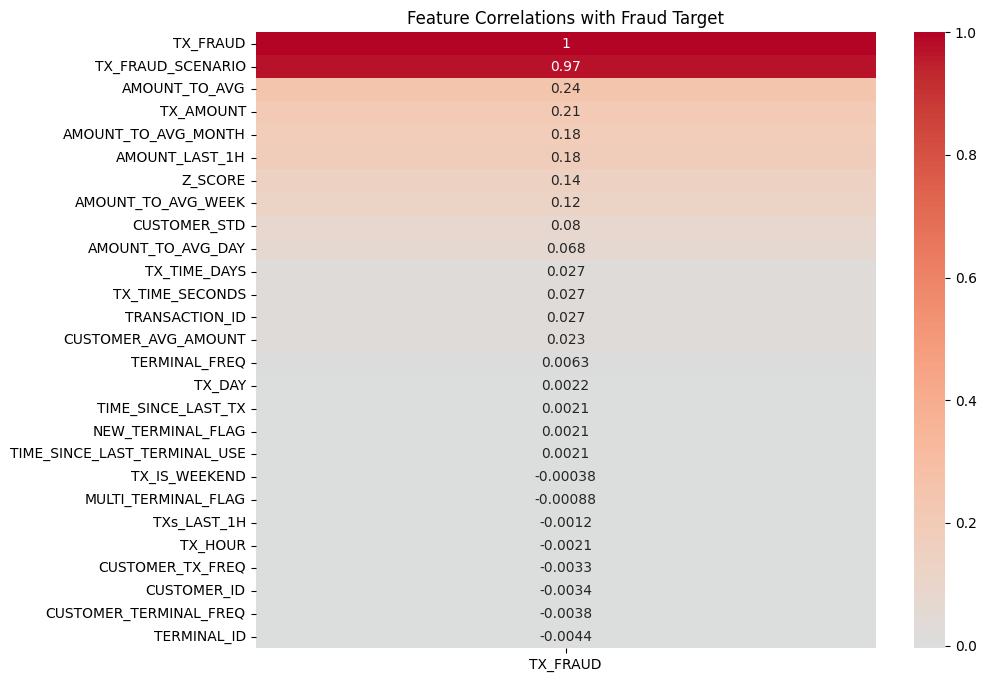

In [9]:
# Downcast numeric columns to save memory
for col in df_transformed.select_dtypes(include=['int64']):
    df_transformed[col] = pd.to_numeric(df_transformed[col], downcast='integer')
    
for col in df_transformed.select_dtypes(include=['float64']):
    df_transformed[col] = pd.to_numeric(df_transformed[col], downcast='float')

# Drop unnecessary columns
columns_to_drop = ['Unnamed: 0', 'Week', 'Month', 'TX_DATETIME']
df_transformed.drop(columns=[col for col in columns_to_drop if col in df_transformed.columns], inplace=True)

# Convert boolean flags to int
bool_cols = df_transformed.select_dtypes(include=['bool']).columns
df_transformed[bool_cols] = df_transformed[bool_cols].astype(int)

# Final validation checks
print("Null values per column:")
print(df_transformed.isnull().sum())

print("\nData types:")
print(df_transformed.dtypes)

"""if 'TX_FRAUD' in df_transformed.columns:
    print("\nCorrelation with target:")
    print(df_transformed.corr()['TX_FRAUD'].sort_values(ascending=False,  key=lambda col: col.str.lower()))"""
    
#  only numeric columns
if 'TX_FRAUD' in df_transformed.columns:
    print("\nCorrelation with target:")
    
    numeric_cols = df_transformed.select_dtypes(include=[np.number]).columns
    corr_with_target = df_transformed[numeric_cols].corr()['TX_FRAUD'].sort_values(ascending=False)
    display(corr_with_target)
    
    # Optionally visualize correlations
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_transformed[numeric_cols].corr()[['TX_FRAUD']].sort_values('TX_FRAUD', ascending=False), 
                annot=True, cmap='coolwarm', center=0)
    plt.title('Feature Correlations with Fraud Target')
    plt.show()

## Save Transformed Data

In [10]:
# Save full transformed dataset
df_transformed.to_csv('simulated-data-transformed.csv', index=False)

# Save a sample for testing
df_transformed.sample(10000).to_csv('simulated-data-transformed-sample.csv', index=False)

print("Transformation complete. Data saved to:")
print("- simulated-data-transformed.csv")
print("- simulated-data-transformed-sample.csv")

Transformation complete. Data saved to:
- simulated-data-transformed.csv
- simulated-data-transformed-sample.csv


### Plotting the data to get clear insights

Text(0.5, 1.0, 'The Fraud Transactions are 1.51% of the dataset')

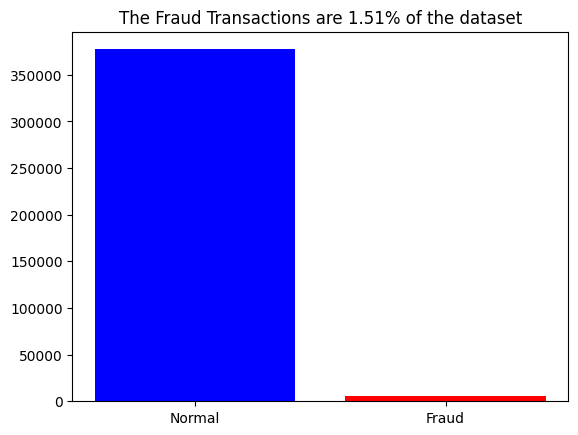

In [11]:
Normal_len = len(df[df["TX_FRAUD"]==0])
Fraud_len = len(df[df["TX_FRAUD"]==1])

plt.bar([0 ,1], [Normal_len, Fraud_len], color=['b' ,'r'])
plt.xticks([0, 1], ["Normal", "Fraud"])

t = round((Fraud_len/len(df) * 100),2)
plt.title(f"The Fraud Transactions are {t}% of the dataset")

<Axes: >

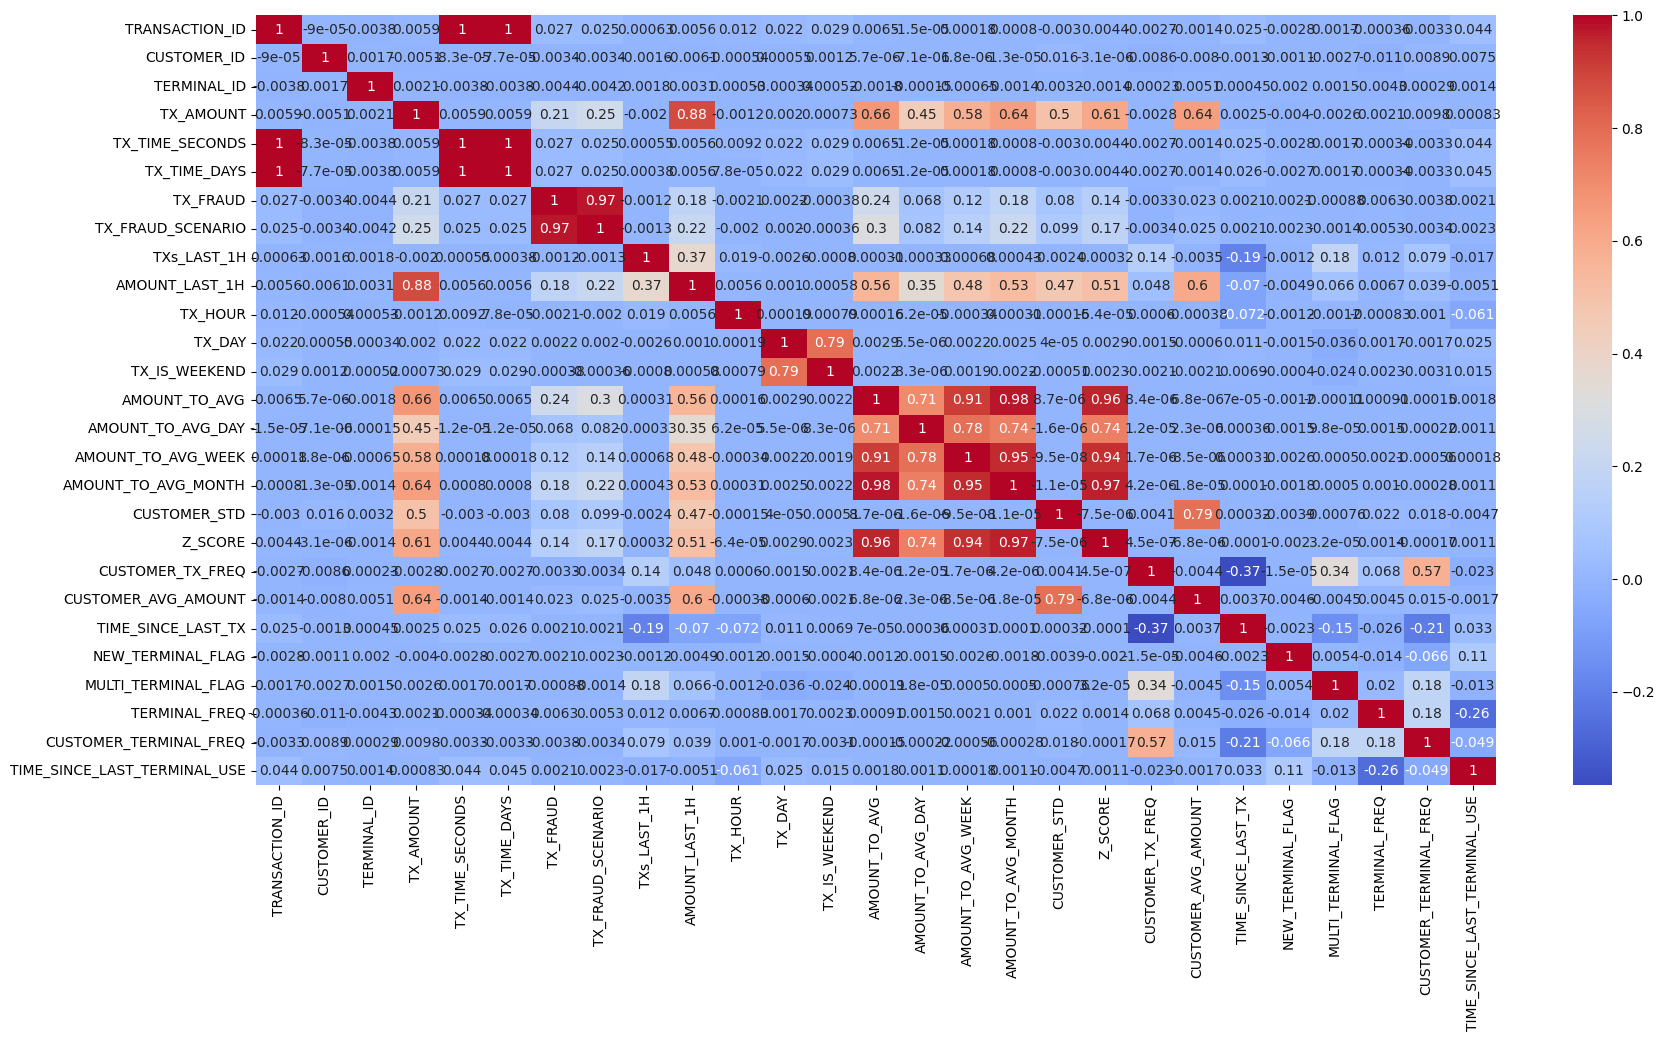

In [12]:
plt.figure(figsize=(20, 10))
sns.heatmap(df_transformed.corr(numeric_only=True), annot=True, cmap="coolwarm")

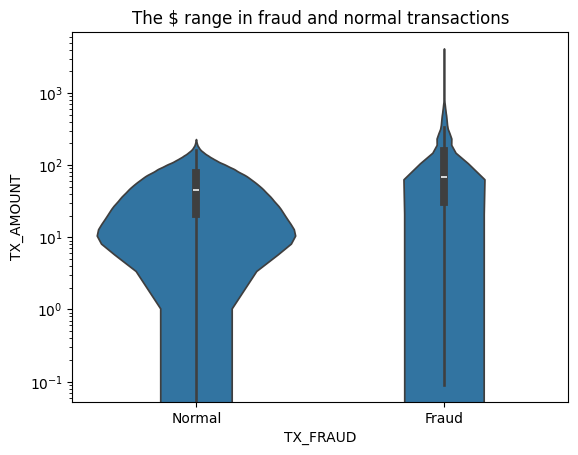

In [13]:
sns.violinplot(x='TX_FRAUD', y='TX_AMOUNT',  data=df_transformed)
plt.xticks([0, 1], ["Normal", "Fraud"])
plt.yscale("log")
plt.title("The $ range in fraud and normal transactions")
plt.show()

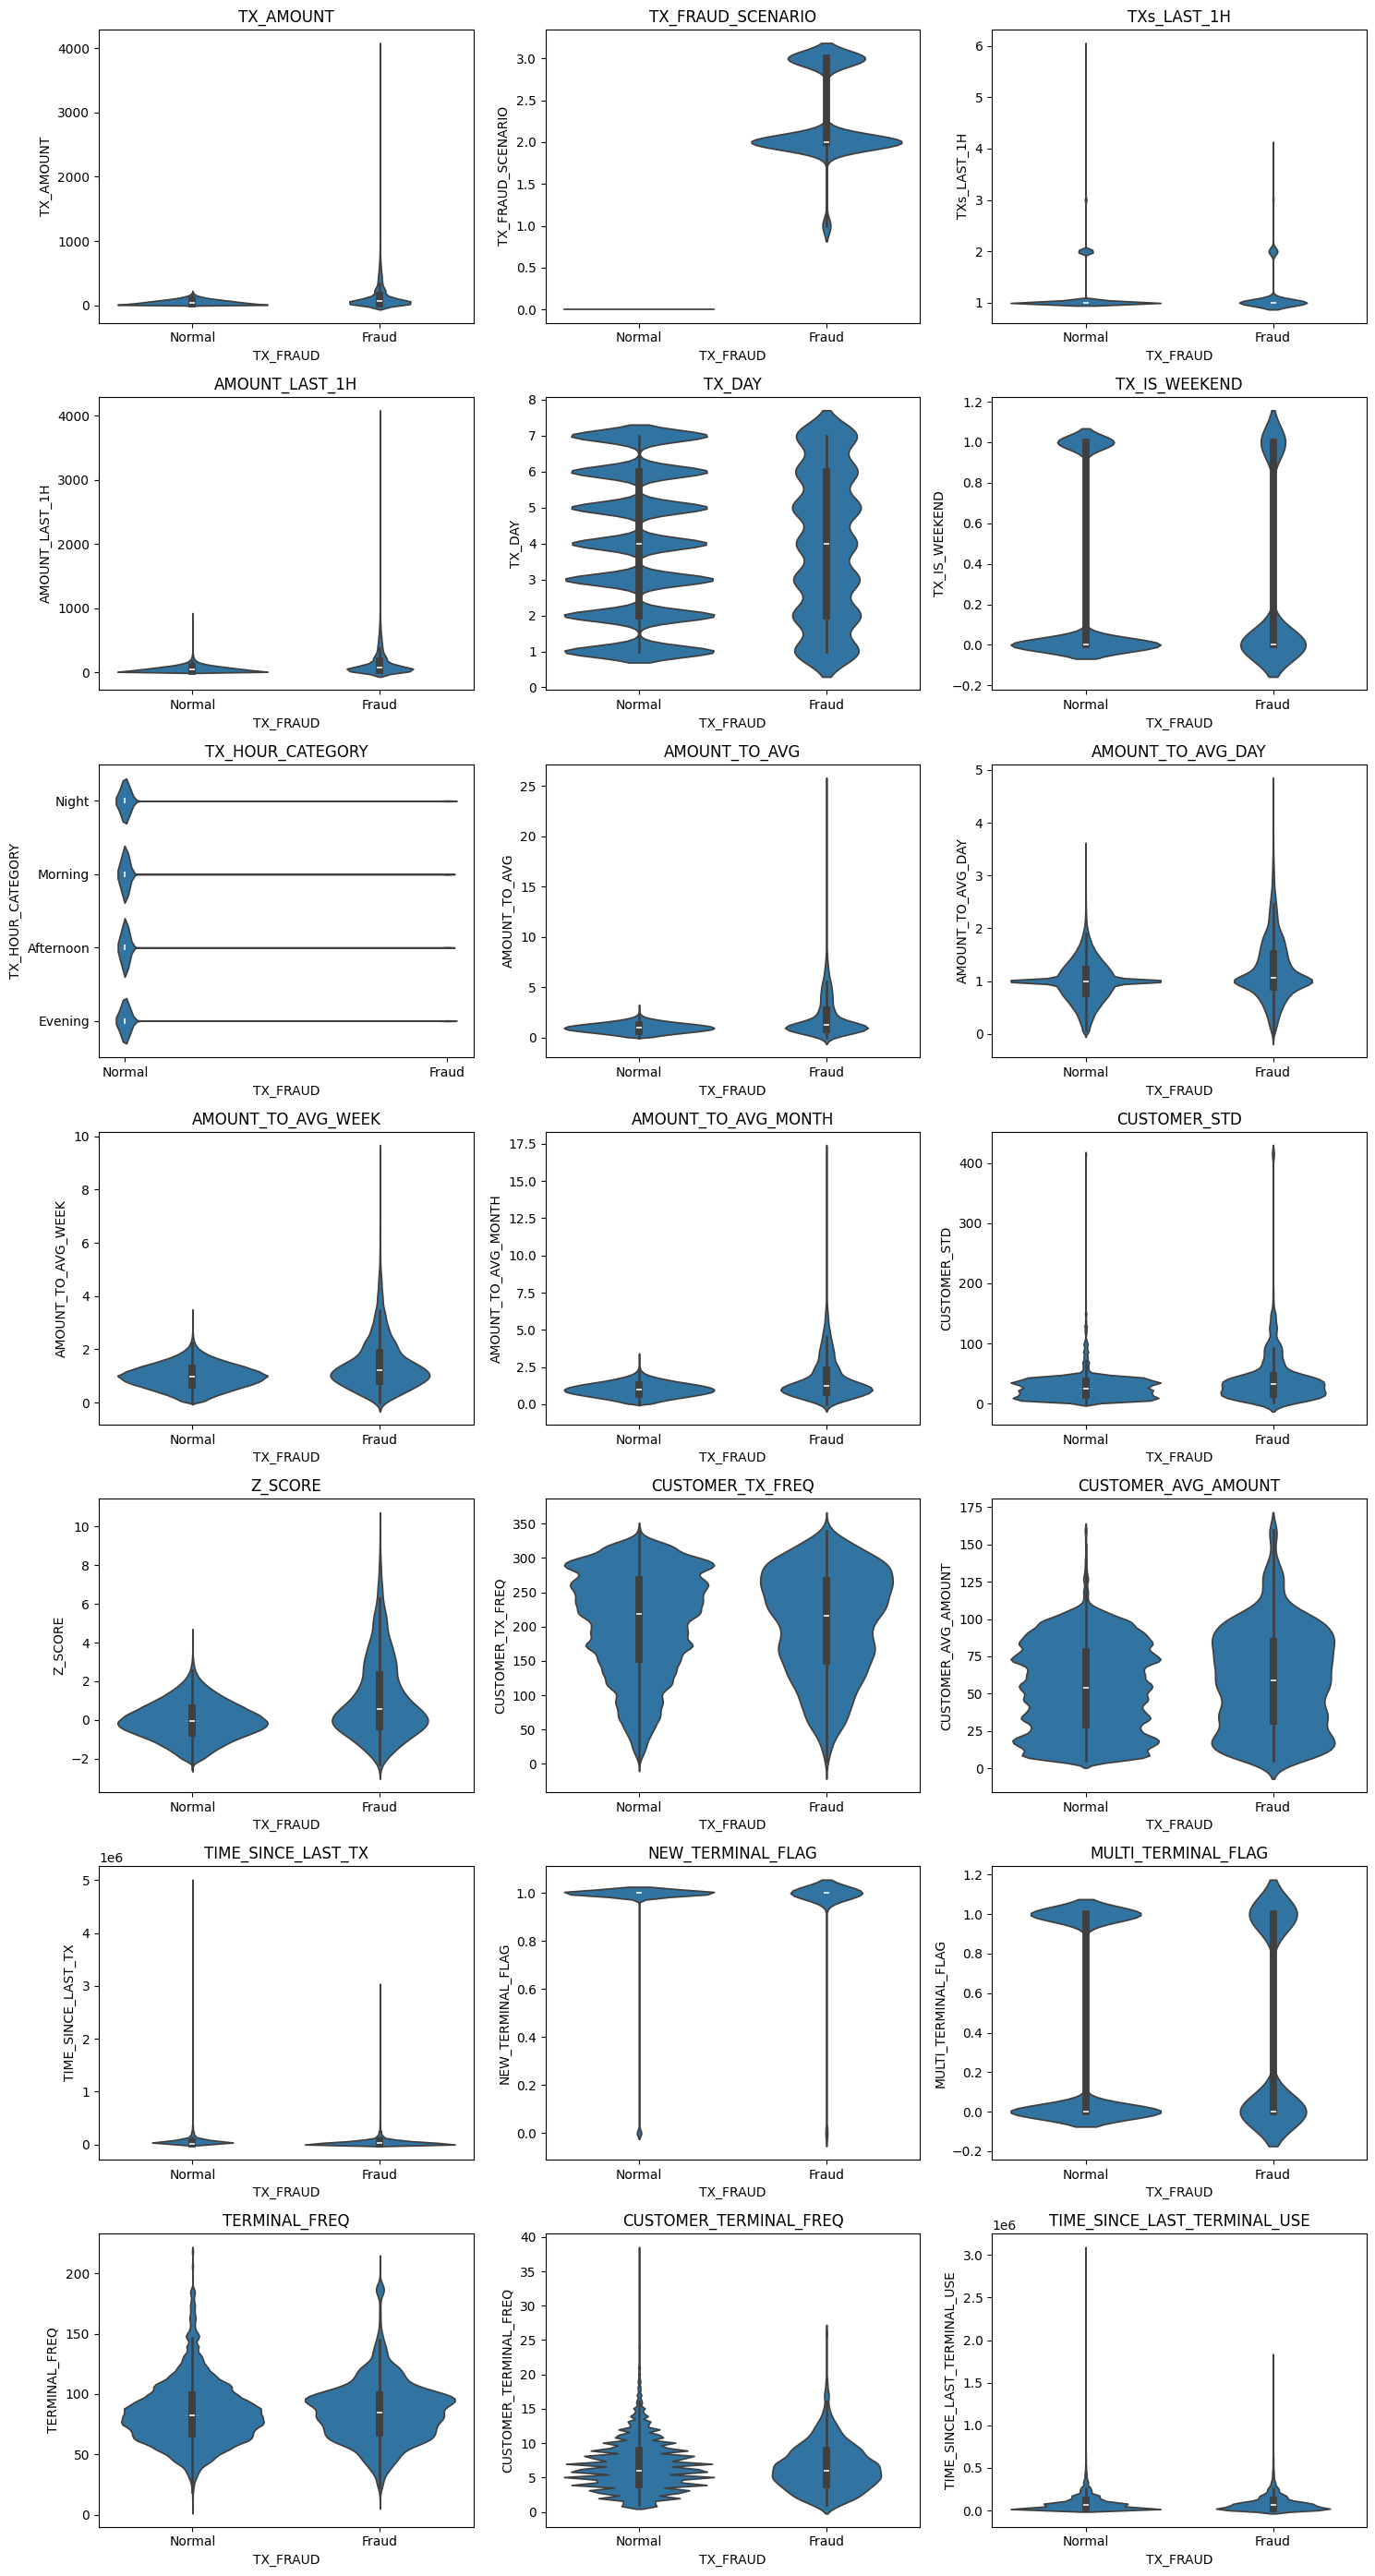

In [14]:
# Columns to exclude
exclude_cols = ["TX_FRAUD", "CUSTOMER_ID", "TRANSACTION_ID", "TX_TIME_SECONDS", "TX_TIME_DAYS", "TERMINAL_ID", "TX_HOUR"]

# Columns to plot
plot_cols = [col for col in df_transformed.columns if col not in exclude_cols]
col_count = len(plot_cols)

# Grid size
cols = 3
rows = math.ceil(col_count / cols)

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

# Plot each violin
for i, col in enumerate(plot_cols):
    sns.violinplot(data=df_transformed, x="TX_FRAUD", y=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Normal", "Fraud"])

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [ ]:
#sns.pairplot(df[['TX_AMOUNT', 'Z_SCORE', 'CUSTOMER_STD', 'TX_FRAUD']], hue='TX_FRAUD')

KeyError: "['Z_SCORE', 'CUSTOMER_STD'] not in index"